## **Import Libraries and modules**

In [ ]:
import numpy as np

from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D

from keras.utils import np_utils

from keras.datasets import mnist

Using TensorFlow backend.


## Load MNIST data into train and test sets

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11493376/11490434 [==============================] - 0s 0us/step


(60000, 28, 28)


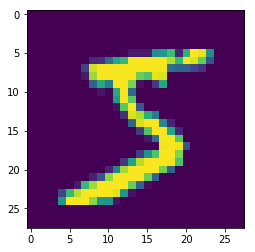

In [ ]:
print (X_train.shape)
from matplotlib import pyplot as plt
%matplotlib inline
plt.imshow(X_train[0])

## Pre-processing

### Reshaping data

In [ ]:
X_train = X_train.reshape(X_train.shape[0], 28, 28,1)
X_test = X_test.reshape(X_test.shape[0], 28, 28,1)

### Pixel Normalization

In [ ]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

In [ ]:
y_train[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

### One-hot encoding

In [ ]:
# Convert 1-dimensional class arrays to 10-dimensional class matrices
Y_train = np_utils.to_categorical(y_train, 10)
Y_test = np_utils.to_categorical(y_test, 10)

In [ ]:
Y_train[:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]], dtype=float32)

In [ ]:
model = Sequential()

model.add(Conv2D(4, (3, 3), activation='relu', input_shape=(28,28,1)))

model.add(Conv2D(8, (3, 3), activation='relu'))
model.add(Conv2D(16, (3, 3), activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(4, (1, 1), activation='relu'))

model.add(Conv2D(8, (3, 3), activation='relu'))
model.add(Conv2D(16, (3, 3), activation='relu'))

model.add(Conv2D(10, (1, 1), activation='relu'))
model.add(Conv2D(10, (7, 7)))

model.add(GlobalAveragePooling2D())

model.add(Activation('softmax'))

model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_9 (Conv2D)            (None, 26, 26, 4)         40        
_________________________________________________________________
conv2d_10 (Conv2D)           (None, 24, 24, 8)         296       
_________________________________________________________________
conv2d_11 (Conv2D)           (None, 22, 22, 16)        1168      
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 11, 11, 16)        0         
_________________________________________________________________
conv2d_12 (Conv2D)           (None, 11, 11, 4)         68        
_________________________________________________________________
conv2d_13 (Conv2D)           (None, 9, 9, 8)           296       
_________________________________________________________________
conv2d_14 (Conv2D)           (None, 7, 7, 16)         

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer= 'adam', metrics=['accuracy'])
model.fit(X_train, Y_train, batch_size=32, epochs=3, verbose=1, validation_data=(X_test, Y_test))

Train on 60000 samples, validate on 10000 samples
Epoch 1/3
60000/60000 [==============================] - 22s 361us/step - loss: 0.2307 - acc: 0.9287 - val_loss: 0.0874 - val_acc: 0.9729
Epoch 2/3
60000/60000 [==============================] - 21s 346us/step - loss: 0.0821 - acc: 0.9748 - val_loss: 0.0819 - val_acc: 0.9732
Epoch 3/3
60000/60000 [==============================] - 21s 349us/step - loss: 0.0622 - acc: 0.9809 - val_loss: 0.0603 - val_acc: 0.9808


## Model Building -- Using GAP

In [ ]:
model = Sequential()

model.add(Conv2D(10, 3, 3, activation='relu', input_shape=(28,28,1)))

model.add(Conv2D(10, 3, 3, activation='relu'))

model.add(Conv2D(10, 3, 3, activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(10, 3, 3, activation='relu'))

model.add(Conv2D(10, 3, 3, activation='relu'))

model.add(Conv2D(10, 3, 3, activation='relu'))

model.add(Conv2D(10, 3, 3, activation='relu'))

#model.add(Conv2D(10, 3, 3, activation='relu'))
#model.add(Flatten())

model.add(GlobalAveragePooling2D())

model.add(Activation('softmax'))

model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_25 (Conv2D)           (None, 26, 26, 10)        100       
_________________________________________________________________
conv2d_26 (Conv2D)           (None, 24, 24, 10)        910       
_________________________________________________________________
conv2d_27 (Conv2D)           (None, 22, 22, 10)        910       
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 11, 11, 10)        0         
_________________________________________________________________
conv2d_28 (Conv2D)           (None, 9, 9, 10)          910       
_________________________________________________________________
conv2d_29 (Conv2D)           (None, 7, 7, 10)          910       
_________________________________________________________________
conv2d_30 (Conv2D)           (None, 5, 5, 10)          910       
__________

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:6: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(10, (3, 3), activation="relu", input_shape=(28, 28, 1...)`
  
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:10: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(10, (3, 3), activation="relu")`
  # Remove the CWD from sys.path while we load stuff.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:14: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(10, (3, 3), activation="relu")`
  
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:22: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(10, (3, 3), activation="relu")`
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:26: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(10, (3, 3), activation="relu")`
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:30: UserWarning: Update your `Con

In [ ]:
model.compile(loss='categorical_crossentropy',
             optimizer='sgd',
             metrics=['accuracy'])

model.fit(X_train, Y_train, batch_size=32, epochs=10, verbose=1)

W0822 14:15:55.253913 139995362604928 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/optimizers.py:790: The name tf.train.Optimizer is deprecated. Please use tf.compat.v1.train.Optimizer instead.

W0822 14:15:55.296160 139995362604928 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:3295: The name tf.log is deprecated. Please use tf.math.log instead.

W0822 14:15:55.448166 139995362604928 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
W0822 14:15:55.573950 139995362604928 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:986: The name tf.assign_add is deprecated

Epoch 1/10
60000/60000 [==============================] - 20s 340us/step - loss: 2.2408 - acc: 0.1989
Epoch 2/10
60000/60000 [==============================] - 15s 242us/step - loss: 0.8218 - acc: 0.7398
Epoch 3/10
60000/60000 [==============================] - 15s 242us/step - loss: 0.2612 - acc: 0.9193
Epoch 4/10
60000/60000 [==============================] - 14s 241us/step - loss: 0.1642 - acc: 0.9484
Epoch 5/10
60000/60000 [==============================] - 14s 241us/step - loss: 0.1294 - acc: 0.9596
Epoch 6/10
60000/60000 [==============================] - 15s 243us/step - loss: 0.1094 - acc: 0.9657
Epoch 7/10
60000/60000 [==============================] - 15s 242us/step - loss: 0.0962 - acc: 0.9704
Epoch 8/10
60000/60000 [==============================] - 15s 244us/step - loss: 0.0878 - acc: 0.9729
Epoch 9/10
60000/60000 [==============================] - 15s 243us/step - loss: 0.0809 - acc: 0.9752
Epoch 10/10
60000/60000 [==============================] - 14s 240us/step - loss: 

### Model Evaluation

In [ ]:
score = model.evaluate(X_test, Y_test, verbose=0)
print(score)

[0.06296095959562809, 0.9818]


### Model Prediction

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:9])
print(y_test[:9])

[[2.3371644e-10 1.6188424e-09 1.3586452e-07 6.1056411e-08 1.9976114e-10
  2.1782981e-10 1.9976114e-10 9.9999976e-01 2.9795957e-10 1.2359225e-09]
 [5.6937351e-05 6.4923335e-04 9.9916077e-01 3.5906353e-08 2.5332170e-07
  8.4091063e-09 1.3267882e-04 1.1879364e-08 8.3229430e-08 8.6974792e-09]
 [5.5318546e-06 9.9993014e-01 6.6851430e-06 5.5318546e-06 6.3277666e-06
  5.5318546e-06 6.0180550e-06 2.3201259e-05 5.5318546e-06 5.5318546e-06]
 [9.9920470e-01 9.0361038e-07 8.8355882e-06 9.0257771e-07 9.0257771e-07
  7.1205877e-06 7.0162071e-04 1.3727629e-06 9.0257771e-07 7.2716764e-05]
 [9.0214279e-08 1.3110449e-07 7.5319079e-08 2.0476034e-07 9.9997401e-01
  8.3169382e-08 1.0430471e-06 7.5319079e-08 7.5319079e-08 2.4251212e-05]
 [3.5969824e-06 9.9995458e-01 4.0947366e-06 3.5379217e-06 5.8425280e-06
  3.5379217e-06 5.8491623e-06 1.1935488e-05 3.5379217e-06 3.5379217e-06]
 [9.6139876e-05 3.7589762e-03 1.2958373e-04 9.6139876e-05 9.9397570e-01
  1.2379359e-04 9.6139876e-05 1.6459245e-04 2.4857791e-04 

# Model is not dependent on size of the image.

In [ ]:
model = Sequential()

model.add(Conv2D(10, 3, 3, activation='relu', input_shape=(None,None,1)))
model.add(Conv2D(10, 3, 3, activation='relu'))
model.add(Conv2D(10, 3, 3, activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(10, 3, 3, activation='relu'))
model.add(Conv2D(10, 3, 3, activation='relu'))
model.add(Conv2D(10, 3, 3, activation='relu'))
model.add(Conv2D(10, 3, 3, activation='relu'))

#model.add(Conv2D(10, 3, 3, activation='relu'))
#model.add(Flatten())

model.add(GlobalAveragePooling2D())
model.add(Activation('softmax'))

model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_39 (Conv2D)           (None, None, None, 10)    100       
_________________________________________________________________
conv2d_40 (Conv2D)           (None, None, None, 10)    910       
_________________________________________________________________
conv2d_41 (Conv2D)           (None, None, None, 10)    910       
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, None, None, 10)    0         
_________________________________________________________________
conv2d_42 (Conv2D)           (None, None, None, 10)    910       
_________________________________________________________________
conv2d_43 (Conv2D)           (None, None, None, 10)    910       
_________________________________________________________________
conv2d_44 (Conv2D)           (None, None, None, 10)    910       
__________

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:3: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(10, (3, 3), activation="relu", input_shape=(None, Non...)`
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:5: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(10, (3, 3), activation="relu")`
  """
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:7: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(10, (3, 3), activation="relu")`
  import sys
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:11: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(10, (3, 3), activation="relu")`
  # This is added back by InteractiveShellApp.init_path()
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:13: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(10, (3, 3), activation="relu"

In [ ]:
model.compile(loss='categorical_crossentropy',
             optimizer='sgd',
             metrics=['accuracy'])

model.fit(X_train, Y_train, batch_size=32, epochs=2, verbose=1)

Epoch 1/2
60000/60000 [==============================] - 15s 248us/step - loss: 1.4531 - acc: 0.5357
Epoch 2/2
60000/60000 [==============================] - 15s 243us/step - loss: 1.1529 - acc: 0.6379
